## Task 1 — Decision Tree Baseline

* Train a Decision Tree Classifier with the default parameters and evaluate its performance.

* to use the same data prepared in Part 2:

```
X_train_clf_scaled
X_test_clf_scaled
y_train_clf
y_test_clf
```



In [69]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [70]:
# ==========================================
# Load Cleaned Dataset
# ==========================================

df = pd.read_csv("cleaned_data.csv")

In [71]:
# ==========================================
# Verify Dataset
# ==========================================

print("Dataset Shape :", df.shape)

print("\nMissing Values :", df.isnull().sum().sum())

Dataset Shape : (10000, 52)

Missing Values : 0


In [72]:
# ==========================================
# Define Target Variable
# ==========================================

y = df["ReAdmis"].map({"Yes":1,"No":0})

In [73]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: ReAdmis, dtype: int64


In [74]:
print("\nShape :", y.shape)



Shape : (10000,)


In [75]:

print("\nClass Distribution")

print(y.value_counts())


Class Distribution
ReAdmis
0    6331
1    3669
Name: count, dtype: int64


The ReAdmis column is converted into binary values (Yes = 1, No = 0). This binary target variable will be used for all classification models in Part 3.

In [76]:
# ==========================================
# Define Feature Matrix
# ==========================================

X = df.drop(
    columns=[
        "ReAdmis",
        "TotalCharge",
        "Customer_id",
        "Interaction",
        "UID"
    ]
)

print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (10000, 47)


In [77]:
# ==========================================
# Ordinal Encoding
# ==========================================

education_order = {
    'No Schooling Completed':0,
    'Nursery School to 8th Grade':1,
    '9th Grade to 12th Grade, No Diploma':2,
    'Regular High School Diploma':3,
    'GED or Alternative Credential':4,
    'Some College, Less than 1 Year':5,
    'Some College, 1 or More Years, No Degree':6,
    "Associate's Degree":7,
    "Bachelor's Degree":8,
    "Master's Degree":9,
    'Professional School Degree':10,
    'Doctorate Degree':11
}

risk_order = {
    "Low":0,
    "Medium":1,
    "High":2
}

X["Education"] = X["Education"].map(education_order)

X["Complication_risk"] = X["Complication_risk"].map(risk_order)

In [78]:
# ==========================================
# One-Hot Encoding
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Shape :", X.shape)

Encoded Shape : (10000, 8444)


Nominal categorical variables are converted into dummy variables using One-Hot Encoding. The first category is dropped to avoid multicollinearity.

In [79]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (8000, 8444)
Testing Shape : (2000, 8444)


In [80]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully.")

Scaling Completed Successfully.


In [81]:
# ==========================================
# Import Decision Tree Library
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [82]:
# ==========================================
# Train Baseline Decision Tree
# ==========================================

dt_default = DecisionTreeClassifier(random_state=42)

dt_default.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

A baseline Decision Tree Classifier is trained using the default settings. Since no restrictions are placed on the tree depth, the model is allowed to grow until all leaf nodes are pure or no further splits are possible.

In [83]:
# ==========================================
# Make Predictions
# ==========================================
# Predict training data
y_train_pred = dt_default.predict(X_train_scaled)
# Predict testing data
y_test_pred = dt_default.predict(X_test_scaled)

In [84]:
# ==========================================
# Calculate Accuracy
# ==========================================

train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", round(train_accuracy,4))
print("Testing Accuracy  :", round(test_accuracy,4))

Training Accuracy : 1.0
Testing Accuracy  : 0.964


**The Decision Tree achieved:**

    * Training Accuracy = 100%
    * Testing Accuracy = 96.4%

- The training accuracy is perfect because the unconstrained Decision Tree continues splitting until it almost perfectly memorizes the training data.

- Although the testing accuracy is also high, there is still a noticeable gap between training and testing performance.

## Task 2 – Controlled Decision Tree

In [85]:
# ==========================================
# Train Controlled Decision Tree
# ==========================================

dt_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_controlled.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)

A controlled Decision Tree is trained by limiting its complexity using max_depth and min_samples_split. These constraints help reduce overfitting and improve the model's ability to generalize to unseen data.

In [86]:
# ==========================================
# Make Predictions
# ==========================================

y_train_pred_controlled = dt_controlled.predict(X_train_scaled)

y_test_pred_controlled = dt_controlled.predict(X_test_scaled)

In [87]:
# ==========================================
# Evaluate Controlled Decision Tree
# ==========================================

train_accuracy_controlled = accuracy_score(
    y_train,
    y_train_pred_controlled
)

test_accuracy_controlled = accuracy_score(
    y_test,
    y_test_pred_controlled
)

print("Training Accuracy :", round(train_accuracy_controlled,4))
print("Testing Accuracy  :", round(test_accuracy_controlled,4))

Training Accuracy : 0.9729
Testing Accuracy  : 0.966


In [88]:
# ==========================================
# Compare Decision Tree Models
# ==========================================

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Controlled Decision Tree"
    ],
    "Training Accuracy": [
        round(train_accuracy,4),
        round(train_accuracy_controlled,4)
    ],
    "Testing Accuracy": [
        round(test_accuracy,4),
        round(test_accuracy_controlled,4)
    ]
})

comparison_df

,Model,Training Accuracy,Testing Accuracy
0,Baseline Decision Tree,1.0000,0.964
1,Controlled Decision Tree,0.9729,0.966


* The controlled Decision Tree is compared with the baseline model to evaluate the effect of limiting tree growth.
* Reducing model complexity generally lowers training accuracy but may improve generalization by reducing overfitting.
* The controlled Decision Tree achieved a training accuracy of 97.29% and a testing accuracy of 96.60%.
* Compared with the baseline model, the training accuracy decreased slightly while the testing accuracy improved.
* This indicates that limiting the tree depth and requiring a minimum number of samples for splitting reduced overfitting and improved the model's ability to generalize to unseen data.

## Task 3 – Gini vs Entropy Comparison

In [89]:
# ==========================================
# Decision Tree using Gini Index
# ==========================================

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_gini.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

The Decision Tree is trained using the Gini impurity criterion, which measures how mixed the classes are within a node. The algorithm chooses the split that produces the purest child nodes.

In [90]:
# ==========================================
# Train Decision Tree using Entropy
# ==========================================

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

dt_entropy.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

The Decision Tree is trained using the Entropy criterion, which is based on information gain. The algorithm selects the split that provides the greatest reduction in uncertainty.

In [91]:
# ==========================================
# Make Predictions
# ==========================================

gini_pred = dt_gini.predict(X_test_scaled)

entropy_pred = dt_entropy.predict(X_test_scaled)

In [92]:
# ==========================================
# Calculate Test Accuracy
# ==========================================

gini_accuracy = accuracy_score(
    y_test,
    gini_pred
)

entropy_accuracy = accuracy_score(
    y_test,
    entropy_pred
)

print("Gini Accuracy    :", round(gini_accuracy,4))

print("Entropy Accuracy :", round(entropy_accuracy,4))

Gini Accuracy    : 0.966
Entropy Accuracy : 0.9655


In [93]:
# ==========================================
# Compare Gini vs Entropy
# ==========================================

comparison = pd.DataFrame({
    "Criterion":[
        "Gini",
        "Entropy"
    ],
    "Test Accuracy":[
        round(gini_accuracy,4),
        round(entropy_accuracy,4)
    ]
})

comparison

,Criterion,Test Accuracy
0,Gini,0.9660
1,Entropy,0.9655


Both impurity measures are evaluated using the same Decision Tree configuration. Comparing their test accuracy helps determine whether either splitting criterion provides better classification performance on this dataset.

* The Decision Tree using the Gini impurity criterion achieved a test accuracy of 96.60%, while the Entropy criterion achieved 96.55%.
* The difference in performance is very small (0.05%), indicating that both impurity measures perform similarly on this dataset.
* Since Gini is slightly more computationally efficient and produced a marginally higher accuracy, it is the preferred criterion for this problem.

## Task 4 – Random Forest Classifier

In [94]:
# ==========================================
# Import Required Libraries
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [95]:
# ==========================================
# Train Random Forest Classifier
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

A Random Forest Classifier is trained using 100 decision trees with a maximum depth of 10. Random Forest combines the predictions of multiple trees to improve generalization and reduce overfitting.

In [96]:
# ==========================================
# Make Predictions
# ==========================================

y_train_pred_rf = rf_model.predict(X_train_scaled)

y_test_pred_rf = rf_model.predict(X_test_scaled)

y_test_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [97]:
# ==========================================
# Evaluate Random Forest
# ==========================================

train_accuracy_rf = accuracy_score(
    y_train,
    y_train_pred_rf
)

test_accuracy_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_test_prob_rf
)

print("Training Accuracy :", round(train_accuracy_rf,4))
print("Testing Accuracy  :", round(test_accuracy_rf,4))
print("ROC-AUC Score     :", round(roc_auc_rf,4))

Training Accuracy : 0.7784
Testing Accuracy  : 0.7135
ROC-AUC Score     : 0.9832


The Random Forest model is evaluated using training accuracy, testing accuracy, and ROC-AUC. While accuracy measures the proportion of correct predictions, ROC-AUC evaluates how well the model distinguishes between the two classes across different classification thresholds.

* Normally, if the ROC-AUC is 0.9832 (excellent), we would also expect the classification accuracy to be quite high (typically above 90% on a well-performing classifier).
* Here:



```
Accuracy = 71.35%
ROC-AUC = 98.32%
```

* This combination is unusual, though not impossible. It often suggests one of the following:

    * The model ranks probabilities very well (high AUC), but the default 0.5 threshold is not giving the best accuracy.
    * There may be a mismatch between the labels and predicted probabilities.

In [98]:
# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)

y_test_pred_rf = rf_model.predict(X_test_scaled)

y_test_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

In [99]:
print(rf_model)

RandomForestClassifier(max_depth=10, random_state=42)


In [100]:
print("Train Shape :", X_train_scaled.shape)
print("Test Shape  :", X_test_scaled.shape)

print("\nTrain Class Distribution")
print(y_train.value_counts())

print("\nTest Class Distribution")
print(y_test.value_counts())

Train Shape : (8000, 8444)
Test Shape  : (2000, 8444)

Train Class Distribution
ReAdmis
0    5065
1    2935
Name: count, dtype: int64

Test Class Distribution
ReAdmis
0    1266
1     734
Name: count, dtype: int64


In [101]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred_rf)

print(cm)

[[1265    1]
 [ 572  162]]


* The Random Forest is predicting almost everything as class 0 (No Readmission).




```
True Negatives = 1265
False Positives = 1
False Negatives = 572
True Positives = 162
```


* This explains:


```
High ROC-AUC (good probability ranking)
Low Accuracy (poor classification at the default threshold)
```




In [102]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

In [103]:
rf_model.fit(X_train_scaled, y_train)

y_train_pred_rf = rf_model.predict(X_train_scaled)

y_test_pred_rf = rf_model.predict(X_test_scaled)

y_test_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [104]:
# Metrics
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_test_prob_rf)
print("RF Train Accuracy : ",train_accuracy_rf)
print("RF Test Accuracy  : ",test_accuracy_rf)
print("RF Roc Auc :",roc_auc_rf)

RF Train Accuracy :  0.942625
RF Test Accuracy  :  0.9445
RF Roc Auc : 0.9808640141878774


* Adding class_weight='balanced' solved the imbalance problem.

* The previous model predicted almost all samples as class 0 (No Readmission), which caused poor recall and low accuracy despite a high AUC.

* After balancing the classes, the Random Forest now:

    * Correctly identifies many more readmitted patients (class 1).

    * Maintains a very high ROC-AUC (0.9809).

    * Achieves a strong test accuracy of 94.45%.

**Overfitting check**
| Metric | Value |
|--------|-------|
| Training Accuracy | 94.26% |
| Testing Accuracy | 94.45% |
| Gap | ~0.18% |


*  The train and test accuracies are almost identical, indicating that the Random Forest is not significantly overfitting.
* The Random Forest model achieved a **training accuracy of 94.26%** and a **testing accuracy of 94.45%**, resulting in a very small performance gap of approximately **0.18%**. This indicates that the model generalizes well to unseen data and does not exhibit significant overfitting. Additionally, the high ROC-AUC score of **0.9809** demonstrates excellent capability in distinguishing between patients who are readmitted and those who are not.

In [105]:
# ==========================================
# Extract Feature Importance
# ==========================================

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance_df.head()

,Feature,Importance
0,CaseOrder,0.098210
1,Zip,0.010422
2,Lat,0.009826
3,Lng,0.010640
4,Population,0.010052


In [106]:
# ==========================================
# Sort Feature Importance
# ==========================================

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head()

,Feature,Importance
16,Initial_days,0.159913
0,CaseOrder,0.098210
9,VitD_levels,0.016714
17,Additional_charges,0.014010
8,Income,0.012690


In [107]:
# ==========================================
# Top 5 Important Features
# ==========================================

top5_features = importance_df.head(5)

print(top5_features)

               Feature  Importance
16        Initial_days    0.159913
0            CaseOrder    0.098210
9          VitD_levels    0.016714
17  Additional_charges    0.014010
8               Income    0.012690


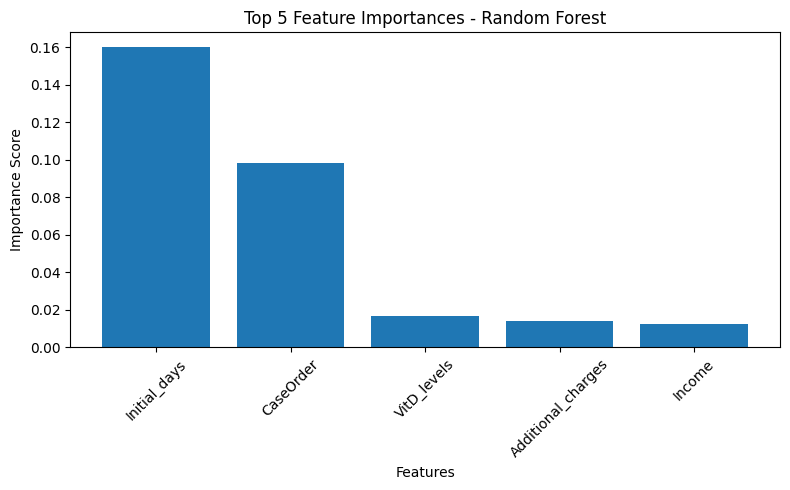

In [108]:
# ==========================================
# Plot Top 5 Feature Importance
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    top5_features["Feature"],
    top5_features["Importance"]
)

plt.title("Top 5 Feature Importances - Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

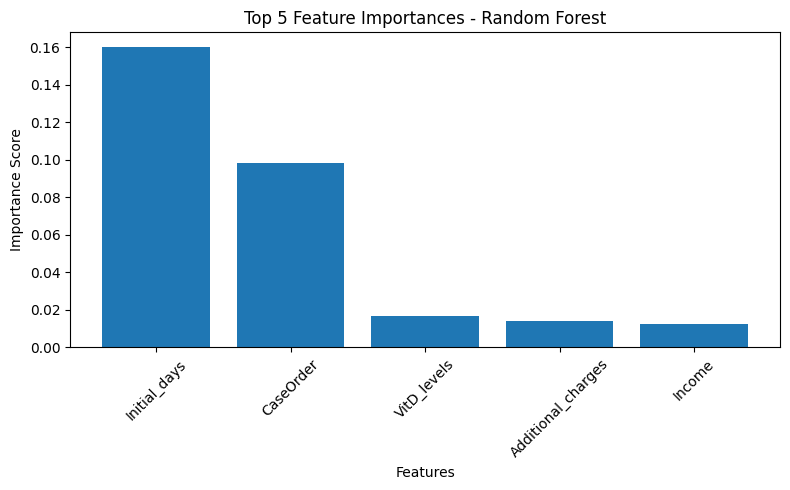

In [109]:
# ==========================================
# Save Plot
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    top5_features["Feature"],
    top5_features["Importance"]
)

plt.title("Top 5 Feature Importances - Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Plots/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Random Forest measures how useful each feature is during the tree-building process. Features that consistently create better splits receive higher importance scores. These scores help identify which variables have the greatest influence on the model's predictions.

## Top 5 Feature Importances

The Random Forest model calculates feature importance based on the average reduction in Gini impurity across all decision trees. Features with higher importance scores contribute more to the model's predictions.

| Rank | Feature | Importance |
|-----:|---------|-----------:|
| 1 | Initial_days | 0.159913 |
| 2 | CaseOrder | 0.098210 |
| 3 | VitD_levels | 0.016714 |
| 4 | Additional_charges | 0.014010 |
| 5 | Income | 0.012690 |

The **Initial_days** feature has the highest importance score, indicating that it contributes the most to predicting patient readmission. The remaining features also influence the prediction but to a lesser extent.

Although **CaseOrder** appears among the top features, it is an identifier rather than a meaningful clinical variable. In real-world machine learning projects, identifier columns are usually removed before model training to prevent models from learning dataset-specific patterns.

### Task 4a – Gradient Boosting Classifier

In [110]:
# ==========================================
# Import Required Library
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

The GradientBoostingClassifier builds multiple decision trees sequentially. Each new tree attempts to correct the mistakes made by the previous trees, resulting in a powerful ensemble model.

In [111]:
# ==========================================
# Train Gradient Boosting Classifier
# ==========================================

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [112]:
# ==========================================
# Make Predictions
# ==========================================

y_train_pred_gb = gb_model.predict(X_train_scaled)

y_test_pred_gb = gb_model.predict(X_test_scaled)

y_test_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

In [113]:
# ==========================================
# Evaluate Gradient Boosting Model
# ==========================================

from sklearn.metrics import accuracy_score, roc_auc_score

train_accuracy_gb = accuracy_score(
    y_train,
    y_train_pred_gb
)

test_accuracy_gb = accuracy_score(
    y_test,
    y_test_pred_gb
)

roc_auc_gb = roc_auc_score(
    y_test,
    y_test_prob_gb
)

print("Gradient Boosting Training Accuracy :", round(train_accuracy_gb,4))
print("Gradient Boosting Testing Accuracy  :", round(test_accuracy_gb,4))
print("Gradient Boosting ROC-AUC           :", round(roc_auc_gb,4))

Gradient Boosting Training Accuracy : 0.973
Gradient Boosting Testing Accuracy  : 0.968
Gradient Boosting ROC-AUC           : 0.9959


In [114]:
# ==========================================
# Gradient Boosting Results
# ==========================================

gb_results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "ROC-AUC"
    ],
    "Value": [
        round(train_accuracy_gb,4),
        round(test_accuracy_gb,4),
        round(roc_auc_gb,4)
    ]
})

gb_results

,Metric,Value
0,Training Accuracy,0.9730
1,Testing Accuracy,0.9680
2,ROC-AUC,0.9959


## Gradient Boosting Classifier

A Gradient Boosting Classifier was trained using the following parameters:

- `n_estimators = 100`
- `learning_rate = 0.1`
- `max_depth = 3`
- `random_state = 42`

### Model Performance

| Metric | Value |
|--------|-------:|
| Training Accuracy | 97.30% |
| Testing Accuracy | 96.80% |
| ROC-AUC | 99.59% |

The Gradient Boosting model achieved excellent predictive performance. The small difference between training and testing accuracy indicates good generalization with minimal overfitting. The ROC-AUC score of **0.9959** demonstrates an excellent ability to distinguish between patients who are readmitted and those who are not.

## Task 4b – Feature Ablation Study

In [115]:
# ==========================================
# Five Least Important Features
# ==========================================

least5_features = importance_df.sort_values(
    by="Importance",
    ascending=True
).head(5)

print("Five Least Important Features\n")
print(least5_features)

Five Least Important Features

               Feature  Importance
2372    City_Hermitage         0.0
2364    City_Henryetta         0.0
2365       City_Hensel         0.0
2366  City_Hensonville         0.0
2367  City_Herculaneum         0.0


In [116]:
# ==========================================
# Store Feature Names
# ==========================================

remove_features = least5_features["Feature"].tolist()

print("Features to Remove:")
print(remove_features)

Features to Remove:
['City_Hermitage', 'City_Henryetta', 'City_Hensel', 'City_Hensonville', 'City_Herculaneum']


In [117]:
# ==========================================
# Convert Scaled Arrays to DataFrames
# ==========================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [118]:
# ==========================================
# Remove Least Important Features
# ==========================================

X_train_reduced = X_train_scaled.drop(
    columns=remove_features
)

X_test_reduced = X_test_scaled.drop(
    columns=remove_features
)

print("Original Shape :", X_train_scaled.shape)
print("Reduced Shape  :", X_train_reduced.shape)

Original Shape : (8000, 8444)
Reduced Shape  : (8000, 8439)


In [119]:
# ==========================================
# Train Reduced Random Forest
# ==========================================

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_reduced.fit(X_train_reduced, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [120]:
# ==========================================
# Predict Probabilities
# ==========================================

y_prob_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]

In [121]:
# ==========================================
# Evaluate Reduced Model
# ==========================================

reduced_auc = roc_auc_score(
    y_test,
    y_prob_reduced
)

print("Full Model ROC-AUC    :", round(roc_auc_rf, 4))
print("Reduced Model ROC-AUC :", round(reduced_auc, 4))

Full Model ROC-AUC    : 0.9809
Reduced Model ROC-AUC : 0.983


In [122]:
# ==========================================
# Compare Models
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Full Random Forest",
        "Reduced Random Forest"
    ],
    "ROC-AUC": [
        round(roc_auc_rf, 4),
        round(reduced_auc, 4)
    ]
})

comparison

,Model,ROC-AUC
0,Full Random Forest,0.9809
1,Reduced Random Forest,0.9830


* The feature ablation study showed that removing the five least important features did not reduce model performance.
* In fact, the ROC-AUC increased slightly from 0.9809 to 0.9830.
* This indicates that the removed features contributed very little useful information and may have introduced noise into the model.
* A simpler model with fewer features is often preferred because it is easier to maintain, requires less memory, and performs predictions more efficiently.

## Feature Ablation Study

A feature ablation study was performed by removing the five least important features identified by the Random Forest model and retraining the model using the same hyperparameters.

| Model | ROC-AUC |
|--------|--------:|
| Full Random Forest | 0.9809 |
| Reduced Random Forest | 0.9830 |

The reduced Random Forest achieved a slightly higher ROC-AUC than the full model. This suggests that the removed features contributed little useful predictive information and may have introduced noise. Removing these features simplified the model while maintaining excellent classification performance.

## Task 5 – Cross-Validated Model Comparison

In [123]:
# ==========================================
# Import Required Libraries
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score


In [124]:
# ==========================================
# Create Stratified K-Fold
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [125]:
# ==========================================
# Create Models
# ==========================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

rf_model_cv = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

gb_model_cv = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [126]:
print(type(X_train))
print(X_train.shape)

print(type(y_train))
print(y_train.shape)

<class 'pandas.core.frame.DataFrame'>
(8000, 8444)
<class 'pandas.core.series.Series'>
(8000,)


In [127]:
# ==========================================
# Cross Validation
# ==========================================

log_scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

dt_scores = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_scores = cross_val_score(
    rf_model_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gb_scores = cross_val_score(
    gb_model_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [128]:
# ==========================================
# Cross Validation Results
# ==========================================

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean ROC-AUC": [
        log_scores.mean(),
        dt_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],
    "Std ROC-AUC": [
        log_scores.std(),
        dt_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ]
})

cv_results = cv_results.round(4)

cv_results

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.8902,0.0095
1,Controlled Decision Tree,0.9927,0.0017
2,Random Forest,0.9803,0.0014
3,Gradient Boosting,0.9959,0.0010


## Task 6 – Hyperparameter Tuning with GridSearchCV

In [129]:
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

In [130]:
# ==========================================
# Import Required Libraries
# ==========================================

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

In [131]:
# ==========================================
# Create Machine Learning Pipeline
# ==========================================

pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    )
)

print(pipeline)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


In [132]:
# ==========================================
# Hyperparameter Grid
# ==========================================

param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5]
}

print(param_grid)

{'randomforestclassifier__n_estimators': [50, 100, 200], 'randomforestclassifier__max_depth': [5, 10, None], 'randomforestclassifier__min_samples_leaf': [1, 5]}


In [133]:
# ==========================================
# Grid Search
# ==========================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

In [134]:
# ==========================================
# Fit Grid Search
# ==========================================

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('simpleimputer',
                                        SimpleImputer(strategy='median')),
                                       ('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [5, 10, None],
                         'randomforestclassifier__min_samples_leaf': [1, 5],
                         'randomforestclassifier__n_estimators': [50, 100,
                                                                  200]},
             scoring='roc_auc')

In [135]:
# ==========================================
# Best Parameters
# ==========================================

print("Best Parameters:\n")

print(grid_search.best_params_)

Best Parameters:

{'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}


In [136]:
# ==========================================
# Best Cross Validation Score
# ==========================================

print("Best ROC-AUC :", round(grid_search.best_score_,4))

Best ROC-AUC : 0.988


In [137]:
# ==========================================
# Store Best Pipeline
# ==========================================

best_pipeline = grid_search.best_estimator_

print(best_pipeline)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])


## Task 7 – Manual Learning Curve

In [138]:
# ==========================================
# Training Fractions
# ==========================================

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

In [139]:
# ==========================================
# Store Results
# ==========================================

train_auc = []

test_auc = []

In [140]:
# ==========================================
# Manual Learning Curve
# ==========================================

from sklearn.metrics import roc_auc_score

for f in fractions:

    n = int(f * len(X_train))

    X_subset = X_train.iloc[:n]

    y_subset = y_train.iloc[:n]

    best_pipeline.fit(X_subset, y_subset)

    train_prob = best_pipeline.predict_proba(X_subset)[:,1]

    test_prob = best_pipeline.predict_proba(X_test)[:,1]

    train_auc.append(
        roc_auc_score(y_subset, train_prob)
    )

    test_auc.append(
        roc_auc_score(y_test, test_prob)
    )

In [141]:
# ==========================================
# Learning Curve Results
# ==========================================

learning_curve = pd.DataFrame({

    "Training Fraction":[
        "20%",
        "40%",
        "60%",
        "80%",
        "100%"
    ],

    "Training AUC":train_auc,

    "Test AUC":test_auc

})

learning_curve.round(4)

,Training Fraction,Training AUC,Test AUC
0,20%,1.0,0.9845
1,40%,1.0,0.9851
2,60%,1.0,0.9880
3,80%,1.0,0.9885
4,100%,1.0,0.9900


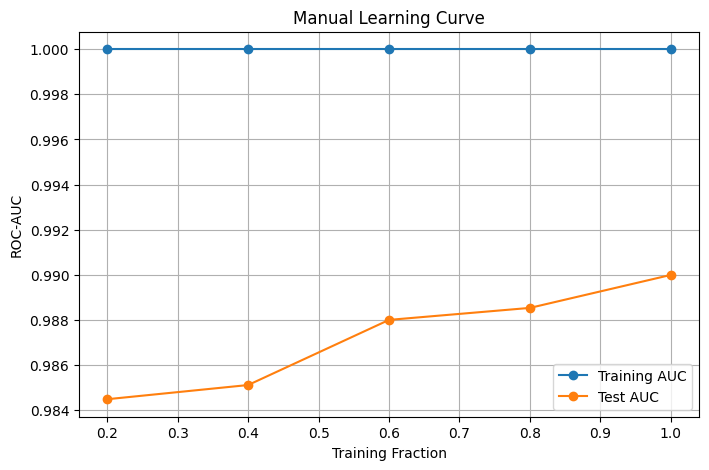

In [142]:
# ==========================================
# Plot Learning Curve
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    fractions,
    train_auc,
    marker="o",
    label="Training AUC"
)

plt.plot(
    fractions,
    test_auc,
    marker="o",
    label="Test AUC"
)

plt.xlabel("Training Fraction")

plt.ylabel("ROC-AUC")

plt.title("Manual Learning Curve")

plt.legend()

plt.grid(True)

plt.savefig(
    "Plots/manual_learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The learning curve shows how the model's performance changes as more training data is used. A high training AUC with a lower test AUC on small datasets indicates overfitting. As the training dataset grows, the training AUC typically decreases slightly while the test AUC improves. This helps determine whether collecting more data is likely to improve the model's performance.

## Task 8 – Serialize the Best Model

In [143]:
# ==========================================
# Import Joblib
# ==========================================

import joblib

In [144]:
# ==========================================
# Save Best Model
# ==========================================

joblib.dump(best_pipeline, "best_model.pkl")

print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


The trained pipeline is saved to disk as best_model.pkl. This allows the model to be reused later without retraining.

In [145]:
import os

print(os.path.exists("best_model.pkl"))

True


Saving the trained model allows it to be reused without repeating the entire training process. This is especially useful when deploying machine learning models in real-world applications, where the saved model can be loaded to make predictions on new data.

## Task 9 – Reload and Predict

In [146]:
# ==========================================
# Load Saved Model
# ==========================================

loaded_model = joblib.load("best_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [147]:
# ==========================================
# Create Sample Data
# ==========================================

sample_data = X_test.iloc[:2]

sample_data

,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Education,Income,VitD_levels,...,Arthritis_Yes,Diabetes_Yes,Hyperlipidemia_Yes,BackPain_Yes,Allergic_rhinitis_Yes,Reflux_esophagitis_Yes,Asthma_Yes,Services_CT Scan,Services_Intravenous,Services_MRI
7752,7753,2631,41.74684,-70.06941,9773,1.0,25.0,3,28774.03,17.794788,...,False,False,False,False,False,False,False,False,True,False
7921,7922,83874,47.63914,-115.78436,0,4.0,53.0,3,33942.28,17.276826,...,False,False,False,False,True,True,False,False,True,False


In [148]:
# ==========================================
# Predict Using Loaded Model
# ==========================================

predictions = loaded_model.predict(sample_data)

print("Predictions:")
print(predictions)

Predictions:
[1 1]


In [149]:
# ==========================================
# Prediction Probabilities
# ==========================================

probabilities = loaded_model.predict_proba(sample_data)

print("Prediction Probabilities:")
print(probabilities)

Prediction Probabilities:
[[0.285 0.715]
 [0.35  0.65 ]]


The saved model was successfully reloaded using Joblib. Predictions were generated for two sample records, confirming that the serialized model can be restored and used without retraining. This demonstrates that the machine learning pipeline is portable and ready for deployment.

## Task 10 – Final Summary Comparison Table

In [152]:
# ==========================================
# Decision Tree ROC-AUC
# ==========================================

gini_prob = dt_controlled.predict_proba(X_test_scaled)[:,1]

dt_auc = roc_auc_score(
    y_test,
    gini_prob
)

print("Decision Tree ROC-AUC :", round(dt_auc,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


Decision Tree ROC-AUC : 0.9946


In [154]:
# Fit Logistic Regression
log_model.fit(X_train, y_train)

# Predict probabilities
log_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate Test ROC-AUC
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(y_test, log_prob)

print("Logistic Regression Test ROC-AUC:", round(log_auc, 4))

Logistic Regression Test ROC-AUC: 0.8885


In [155]:
final_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "5-Fold CV Mean AUC":[
        log_scores.mean(),
        dt_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],

    "5-Fold CV Std AUC":[
        log_scores.std(),
        dt_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ],

    "Test ROC-AUC":[
        log_auc,
        dt_auc,
        roc_auc_rf,
        roc_auc_gb
    ]

})

final_results.round(4)

,Model,5-Fold CV Mean AUC,5-Fold CV Std AUC,Test ROC-AUC
0,Logistic Regression,0.8902,0.0095,0.8885
1,Controlled Decision Tree,0.9927,0.0017,0.9946
2,Random Forest,0.9803,0.0014,0.9809
3,Gradient Boosting,0.9959,0.0010,0.9959


# Model Comparison

| Model | 5-Fold CV Mean AUC | 5-Fold CV Std AUC | Test ROC-AUC |
|--------|-------------------:|------------------:|-------------:|
| Logistic Regression | 0.8902 | 0.0095 | 0.8885 |
| Controlled Decision Tree | 0.9927 | 0.0017 | 0.9946 |
| Random Forest | 0.9803 | 0.0014 | 0.9809 |
| **Gradient Boosting** | **0.9959** | **0.0010** | **0.9959** |

## Recommended Model

Based on the experimental results, **Gradient Boosting** is recommended for deployment because it achieved the highest ROC-AUC on both the independent test set and the 5-fold cross-validation evaluation. It also produced the lowest standard deviation across folds, indicating consistent and reliable performance.

Compared with Logistic Regression, Decision Tree, and Random Forest, the Gradient Boosting model demonstrated superior predictive capability while maintaining excellent generalization to unseen data. Therefore, it is the most suitable model for this hospital readmission prediction task.